# Arvato Customer Segmentation

Customer Segments is a market intelligence project
designed to optimize direct mail marketing for a
German retailer. The company needs to identify
which individuals within the general population are
most likely to become customers, rather than
sending costly marketing materials to everyone at
random.

***Goal is to use unsupervised learning to uncover the "DNA" of the existing customer base.***

#### **Project Plan**

| Phase          | What needs to be done             |
|--------------------|-------------------|
| **1**     | Data Exploration           |
| **2**           | Preprocessing: Missing values, Feature Encoding, Single Automated Cleaning Function    |
| **3**       | Feature Transformation: Feature Scaling, PCA Implementation, Component Analysis  |
| **4**           | Clustering: K-Means Clustering, Customer Mapping, Market Profiling        |  

# Data Exploration

In [1]:
# First, import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


#import plotly.express as px

# Set Float precision
#pd.options.display.float_format = '{:,.3f}'.format

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

c:\Users\mnour\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ Libraries imported successfully!


In [3]:
# Load & Show General Demograhpics Data
data1 = pd.read_csv(r"C:\Users\mnour\Downloads\Task_14-20260411T100317Z-3-001\Task_14\Data\Udacity_AZDIAS_Subset.csv", sep=';')
data1

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891216,-1,3,2,5.0,1,4,2,5,4,4,...,3.0,2.0,0.0,0.0,1.0,2.0,3.0,NaN,NaN,NaN
891217,-1,2,1,4.0,3,3,3,2,2,3,...,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,6.0,5.0
891218,-1,2,2,4.0,2,4,2,5,4,3,...,4.0,2.0,0.0,0.0,1.0,3.0,4.0,2.0,2.0,3.0
891219,-1,1,1,3.0,1,5,3,5,5,5,...,1.0,4.0,3.0,1.0,5.0,1.0,1.0,4.0,7.0,5.0


In [4]:
# Load & Show Customer Demographics Data

data2 = pd.read_csv(r"C:\Users\mnour\Downloads\Task_14-20260411T100317Z-3-001\Task_14\Data\Udacity_CUSTOMERS_Subset.csv", sep=';')
data2

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,...,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1,4,2,2.0,5,1,5,1,4,4,...,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0
3,1,4,1,2.0,5,1,5,2,1,2,...,3.0,2.0,1.0,0.0,1.0,3.0,4.0,1.0,3.0,1.0
4,-1,3,1,6.0,3,1,4,4,5,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,3.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191647,1,3,1,4.0,5,1,5,1,1,2,...,2.0,4.0,2.0,1.0,2.0,5.0,4.0,3.0,8.0,5.0
191648,-1,4,2,2.0,5,1,5,2,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,1.0
191649,2,4,1,2.0,5,1,5,1,1,2,...,3.0,2.0,2.0,1.0,1.0,5.0,5.0,3.0,7.0,5.0
191650,3,3,2,4.0,2,1,5,1,2,5,...,3.0,2.0,1.0,1.0,1.0,2.0,3.0,3.0,4.0,4.0


In [5]:
fsummary = pd.read_csv("AZDIAS_Feature_Summary.csv", sep=";")
fsummary

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]
...,...,...,...,...
80,PLZ8_HHZ,macrocell_plz8,ordinal,[-1]
81,PLZ8_GBZ,macrocell_plz8,ordinal,[-1]
82,ARBEIT,community,ordinal,"[-1,9]"
83,ORTSGR_KLS9,community,ordinal,"[-1,0]"


In [6]:
print("Shape of General Population Demographics Data (AZDIAS):", data1.shape)
print("Shape of Customer Demographics Data:", data2.shape)

Shape of General Population Demographics Data (AZDIAS): (891221, 85)
Shape of Customer Demographics Data: (191652, 85)


In [7]:
data1.describe()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
count,891221.000000,891221.000000,891221.000000,886367.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,...,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,794005.000000,794005.000000,794005.00000
mean,-0.358435,2.777398,1.522098,3.632838,3.074528,2.821039,3.401106,3.033328,2.874167,3.075121,...,2.253330,2.801858,1.595426,0.699166,1.943913,3.612821,3.381087,3.167854,5.293002,3.07222
std,1.198724,1.068775,0.499512,1.595021,1.321055,1.464749,1.322134,1.529603,1.486731,1.353248,...,0.972008,0.920309,0.986736,0.727137,1.459654,0.973967,1.111598,1.002376,2.303739,1.36298
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.00000
25%,-1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,1.000000,0.000000,1.000000,3.000000,3.000000,3.000000,4.000000,2.00000
50%,-1.000000,3.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,2.000000,3.000000,2.000000,1.000000,1.000000,4.000000,3.000000,3.000000,5.000000,3.00000
75%,-1.000000,4.000000,2.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,2.000000,1.000000,3.000000,4.000000,4.000000,4.000000,7.000000,4.00000
max,3.000000,9.000000,2.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,4.000000,4.000000,3.000000,2.000000,5.000000,5.000000,5.000000,9.000000,9.000000,9.00000


In [8]:
data2.describe()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
count,191652.000000,191652.000000,191652.000000,188439.000000,191652.000000,191652.000000,191652.000000,191652.000000,191652.000000,191652.000000,...,138888.000000,138888.000000,138888.000000,138888.000000,138888.000000,138888.000000,138888.000000,141176.000000,141176.000000,141176.000000
mean,0.344359,3.060907,1.376432,3.677928,3.963773,2.057051,4.183317,2.439808,2.646176,2.781176,...,2.537404,2.731510,1.388817,0.539939,1.556607,3.634893,3.622192,2.824850,5.119517,2.898510
std,1.391672,1.086254,0.484492,1.813975,1.036230,1.319422,0.995365,1.697932,1.586506,1.147353,...,0.904927,0.840922,0.885038,0.637048,1.185736,0.933660,1.008472,1.012415,2.159184,1.422683
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,-1.000000,3.000000,1.000000,2.000000,3.000000,1.000000,3.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,1.000000,0.000000,1.000000,3.000000,3.000000,2.000000,4.000000,2.000000
50%,0.000000,3.000000,1.000000,4.000000,4.000000,1.000000,5.000000,2.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,0.000000,1.000000,3.000000,4.000000,3.000000,5.000000,3.000000
75%,2.000000,4.000000,2.000000,6.000000,5.000000,4.000000,5.000000,5.000000,5.000000,3.000000,...,3.000000,3.000000,2.000000,1.000000,1.000000,4.000000,4.000000,4.000000,7.000000,4.000000
max,3.000000,9.000000,2.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,4.000000,4.000000,3.000000,2.000000,5.000000,5.000000,5.000000,9.000000,9.000000,9.000000


In [9]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-null  int64  

In [10]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 191652 entries, 0 to 191651
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               191652 non-null  int64  
 1   ALTERSKATEGORIE_GROB   191652 non-null  int64  
 2   ANREDE_KZ              191652 non-null  int64  
 3   CJT_GESAMTTYP          188439 non-null  float64
 4   FINANZ_MINIMALIST      191652 non-null  int64  
 5   FINANZ_SPARER          191652 non-null  int64  
 6   FINANZ_VORSORGER       191652 non-null  int64  
 7   FINANZ_ANLEGER         191652 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  191652 non-null  int64  
 9   FINANZ_HAUSBAUER       191652 non-null  int64  
 10  FINANZTYP              191652 non-null  int64  
 11  GEBURTSJAHR            191652 non-null  int64  
 12  GFK_URLAUBERTYP        188439 non-null  float64
 13  GREEN_AVANTGARDE       191652 non-null  int64  
 14  HEALTH_TYP             191652 non-null  int64  

# Preprocessing 

In [11]:
missing_before = data1.isna().sum().sum()

for i in range(len(fsummary)):
    col = fsummary.iloc[i]['attribute']
    if col not in data1.columns:
        continue
    
    raw_vals = fsummary.iloc[i]['missing_or_unknown']
    vals = raw_vals.strip('[]').split(',')
    
    cleaned_vals = []
    for v in vals:
        v = v.strip()
        if v == '':
            continue
        elif v in ['X', 'XX']:
            cleaned_vals.append(v)
        else:
            cleaned_vals.append(int(v))
    
    if len(cleaned_vals) == 0:
        continue
        
    data1[col] = data1[col].replace(cleaned_vals, np.nan)

missing_after = data1.isna().sum().sum()

print("Number of naturally missing values is:", missing_before)
print("Total number of missing values after conversion is:", missing_after)

Number of naturally missing values is: 4896838
Total number of missing values after conversion is: 8373929


In [12]:
# How much missing data in each column.
missing_col = (data1.isna().sum()/len(data1))*100
missing_col

AGER_TYP                76.955435
ALTERSKATEGORIE_GROB     0.323264
ANREDE_KZ                0.000000
CJT_GESAMTTYP            0.544646
FINANZ_MINIMALIST        0.000000
                          ...    
PLZ8_HHZ                13.073637
PLZ8_GBZ                13.073637
ARBEIT                  10.926022
ORTSGR_KLS9             10.914689
RELAT_AB                10.926022
Length: 85, dtype: float64

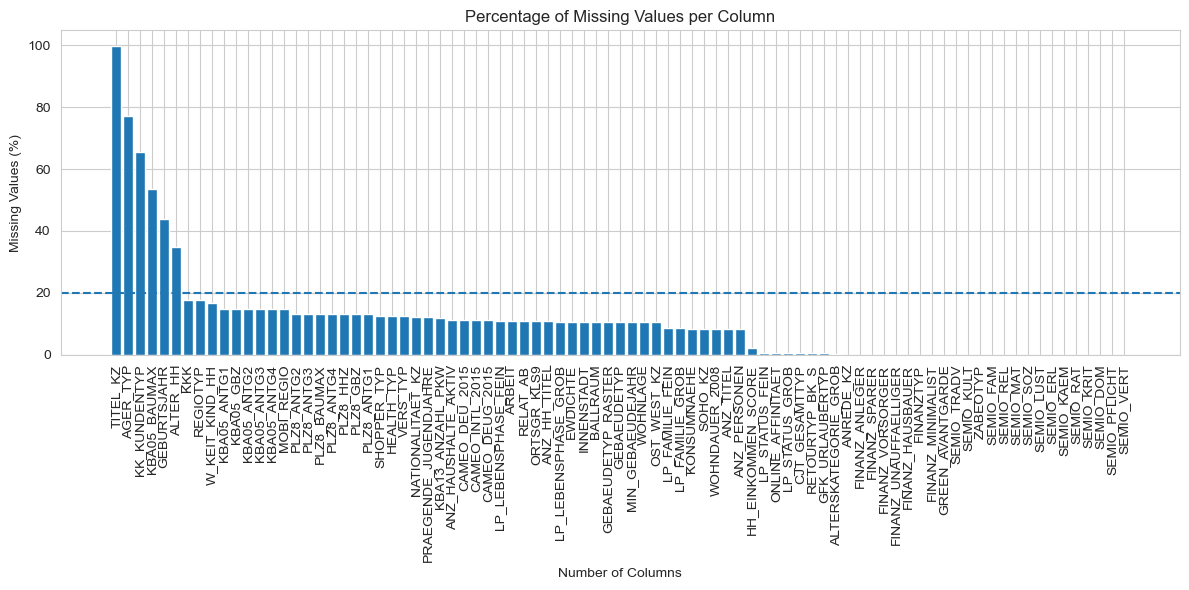

In [13]:
# A plot for missing data per columns
missing_col = missing_col.sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(missing_col.index, missing_col.values)

plt.axhline(y=20, linestyle='--')

plt.xticks(rotation=90)
plt.xlabel("Number of Columns")
plt.ylabel("Missing Values (%)")
plt.title("Percentage of Missing Values per Column")

plt.tight_layout()
plt.show()

In [14]:
missing_col_20perc = missing_col[missing_col > 20]
missing_col_20perc

TITEL_KZ        99.757636
AGER_TYP        76.955435
KK_KUNDENTYP    65.596749
KBA05_BAUMAX    53.468668
GEBURTSJAHR     44.020282
ALTER_HH        34.813699
dtype: float64

In [15]:
# Remove the columns above 20% from the dataset. 
droppedcols_20perc = missing_col_20perc.index.tolist()

data1 = data1.drop(droppedcols_20perc, axis=1)
data1.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2.0,1,2.0,3,4,3,5,5,3,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,2,5.0,1,5,2,5,4,5,1,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,3.0,2,3.0,1,4,1,2,3,5,1,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,4.0,2,2.0,4,2,5,2,1,2,6,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,3.0,1,5.0,4,3,4,1,3,2,5,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [16]:
# Check on missing on each row
row_missing = data1.isnull().sum(axis=1)
row_missing_pct = data1.isnull().sum(axis=1) / data1.shape[1] * 100
row_missing_pct

0         54.430380
1          0.000000
2          0.000000
3          8.860759
4          0.000000
            ...    
891216     3.797468
891217     5.063291
891218     6.329114
891219     0.000000
891220     0.000000
Length: 891221, dtype: float64

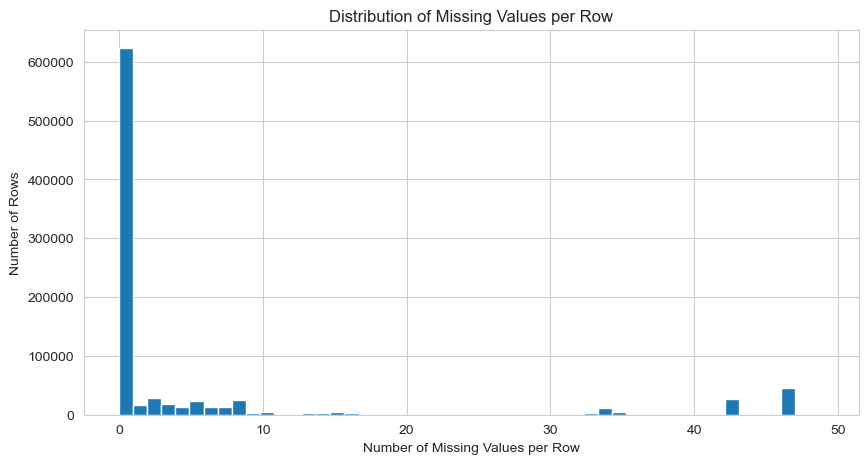

In [17]:
plt.figure(figsize=(10,5))
plt.hist(row_missing, bins=50)
plt.xlabel("Number of Missing Values per Row")
plt.ylabel("Number of Rows")
plt.title("Distribution of Missing Values per Row")
plt.show()

In [18]:
missing_below_20 = data1[row_missing < 20]
missing_above_20 = data1[row_missing >= 20]

missing_above_20perc = np.round(missing_above_20.shape[0]*100 / data1.shape[0],2)

print('Missing Data Rows with above 20 Percentage:', missing_above_20.shape[0])
print(f"Percentage: {missing_above_20perc}%")

Missing Data Rows with above 20 Percentage: 94144
Percentage: 10.56%


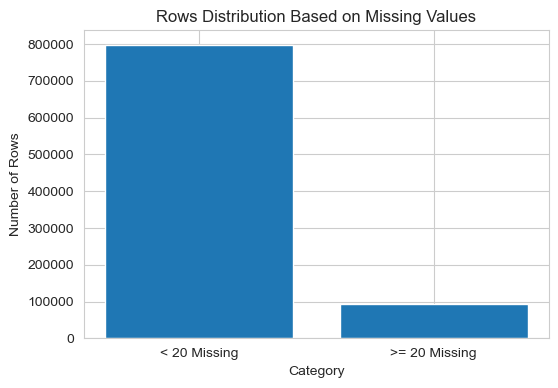

In [19]:
# Bar Chart of missing above and below
labels = ['< 20 Missing', '>= 20 Missing']
values = [missing_below_20.shape[0], missing_above_20.shape[0]]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title('Rows Distribution Based on Missing Values')
plt.ylabel('Number of Rows')
plt.xlabel('Category')
plt.show()

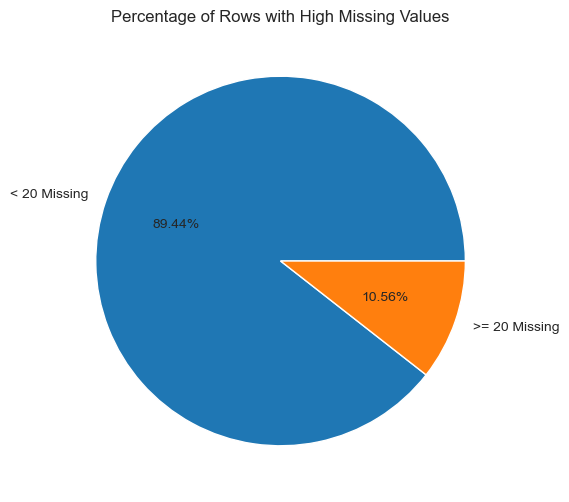

In [20]:
# Pie Chart
sizes = [missing_below_20.shape[0], missing_above_20.shape[0]]
labels = ['< 20 Missing', '>= 20 Missing']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title('Percentage of Rows with High Missing Values')
plt.show()

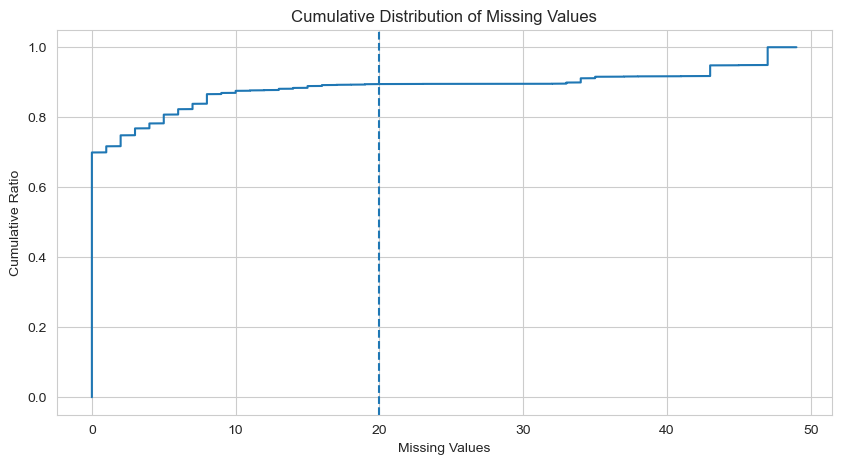

In [21]:
# Cumulative Plot
sorted_missing = np.sort(row_missing)
cumulative = np.arange(len(sorted_missing)) / len(sorted_missing)

plt.figure(figsize=(10,5))
plt.plot(sorted_missing, cumulative)
plt.axvline(20, linestyle='--')
plt.title('Cumulative Distribution of Missing Values')
plt.xlabel('Missing Values')
plt.ylabel('Cumulative Ratio')
plt.show()

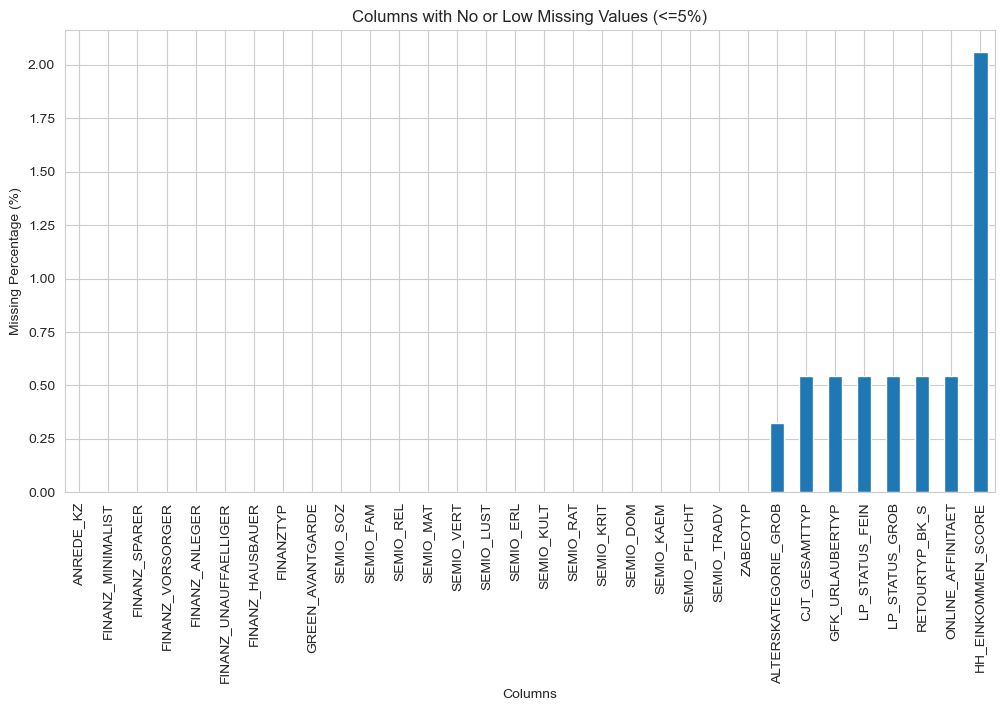

In [22]:
missing_ratio = data1.isna().mean() * 100

no_missing_cols = missing_ratio[missing_ratio == 0]

low_missing_cols = missing_ratio[(missing_ratio > 0) & (missing_ratio <= 5)]

selected_cols = pd.concat([no_missing_cols, low_missing_cols]).sort_values()


plt.figure(figsize=(12,6))
selected_cols.plot(kind='bar')
plt.title('Columns with No or Low Missing Values (<=5%)')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.show()

# Categorical Features Discovery

In [23]:
# First, need to check on data type of each feature.

features_below = list(missing_below_20.columns)
fsummary_clean = fsummary[fsummary['attribute'].isin(features_below)]
fsummary_clean['type'].value_counts()

type
ordinal        49
categorical    18
mixed           6
numeric         6
Name: count, dtype: int64

In [24]:
features_below = list(missing_below_20.columns)
fsummary_clean = fsummary[fsummary['attribute'].isin(features_below)]

cat_features = fsummary_clean[fsummary_clean['type'] == 'categorical']['attribute']

binary_features = []
multi_level_features = []

for feature in cat_features:
    if feature in missing_below_20.columns:
        n_unique = len(missing_below_20[feature].unique())
        
        if n_unique == 2:
            binary_features.append(feature)
        elif n_unique > 2:
            multi_level_features.append(feature)
        
print('Binary features are: {}'.format(binary_features))
print('Multi-level features are: {}'.format(multi_level_features))

Binary features are: ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'OST_WEST_KZ']
Multi-level features are: ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'VERS_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']


In [25]:
# Binary Features Values:
for feature in binary_features:
    print('Unique values for {} are {}'.format(feature, missing_below_20[feature].unique()))

Unique values for ANREDE_KZ are [2 1]
Unique values for GREEN_AVANTGARDE are [0 1]
Unique values for SOHO_KZ are [1. 0.]
Unique values for OST_WEST_KZ are <ArrowStringArray>
['W', 'O']
Length: 2, dtype: str


# Cleaning Function

In [26]:

from sklearn.impute import SimpleImputer

def clean_data(df, feat_info):
    """
    A single, automated function to handle re-encoding, 
    feature engineering, and filtering for the Arvato dataset.
    """
    
    # 1. Start with a copy to avoid changing the original data
    df_clean = df.copy()

    # Step 1: Convert Missing/Unknown codes into NaN Values
    for i in range(len(feat_info)):
        col = feat_info.iloc[i]['attribute']
        if col not in df_clean.columns:
            continue
        
        raw_vals = feat_info.iloc[i]['missing_or_unknown']
        vals = raw_vals.strip('[]').split(',')
        
        cleaned_vals = []
        for v in vals:
            v = v.strip()
            if v == '':
                continue
            elif v in ['X', 'XX']:
                cleaned_vals.append(v)
            else:
                try:
                    num_v = int(v)
                    cleaned_vals.extend([num_v, float(num_v)])
                except ValueError:
                    cleaned_vals.append(v)
        
        if len(cleaned_vals) > 0:
            df_clean[col] = df_clean[col].replace(cleaned_vals, np.nan)
            
    # Step 2: Drop specific columns with high missing values
    # FIX: Removed 'axis=1' because the 'columns' keyword is used
    missing_col_20perc = ["TITEL_KZ", "AGER_TYP", "KK_KUNDENTYP", "KBA05_BAUMAX", "GEBURTSJAHR", "ALTER_HH"]  
    df_clean.drop(columns=missing_col_20perc, errors='ignore', inplace=True)
    
    # Step 3: Drop rows with more than 20 missing values
    df_clean = df_clean[df_clean.isnull().sum(axis=1) <= 20]
    
    # Step 4: Re-encode binary feature (OST_WEST_KZ)
    if 'OST_WEST_KZ' in df_clean.columns:
        df_clean['OST_WEST_KZ'] = df_clean['OST_WEST_KZ'].replace({'W': 0, 'O': 1})
    
    # Step 5: Drop multi-level categorical features
    cat_features = feat_info[feat_info["type"] == "categorical"]["attribute"]
    multi_level_feature = []

    for feature in cat_features:
        if feature in df_clean.columns:
            if df_clean[feature].nunique() > 2:
                multi_level_feature.append(feature)

    # FIX: Removed 'axis=1'
    df_clean.drop(columns=multi_level_feature, errors='ignore', inplace=True)
    
    # Step 6: Engineer Mixed Features
    
    # 6a: PRAEGENDE_JUGENDJAHRE -> DECADE and MOVEMENT
    if 'PRAEGENDE_JUGENDJAHRE' in df_clean.columns:
        decade_dict = {1:1, 2:1, 3:2, 4:2, 5:3, 6:3, 7:3, 8:4, 9:4, 10:5, 11:5, 12:5, 13:5, 14:6, 15:6}
        movement_dict = {1:1, 2:0, 3:1, 4:0, 5:1, 6:0, 7:0, 8:1, 9:0, 10:1, 11:0, 12:1, 13:0, 14:1, 15:0}
        
        df_clean['DECADE'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(decade_dict)
        df_clean['MOVEMENT'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(movement_dict)
    
    # 6b: CAMEO_INTL_2015 -> WEALTH and LIFE_STAGE
    if 'CAMEO_INTL_2015' in df_clean.columns:
        def get_wealth(x):
            if pd.isnull(x) or x == 'XX': return np.nan
            return int(str(x)[0])
        
        def get_lifestage(x):
            if pd.isnull(x) or x == 'XX': return np.nan
            return int(str(x)[1])

        df_clean['WEALTH'] = df_clean['CAMEO_INTL_2015'].apply(get_wealth)
        df_clean['LIFE_STAGE'] = df_clean['CAMEO_INTL_2015'].apply(get_lifestage)
    
    # Step 7: Drop all original mixed features
    mixed_features = feat_info[feat_info["type"] == "mixed"]["attribute"]
    # FIX: Removed 'axis=1'
    df_clean.drop(columns=[f for f in mixed_features if f in df_clean.columns], errors='ignore', inplace=True)
    
    return df_clean




# Feature Transformation

In [27]:
azdias_cleaned = clean_data(data1, fsummary)

imputer = SimpleImputer(strategy='most_frequent')
azdias_imputed_array = imputer.fit_transform(azdias_cleaned)

azdias_imputed = pd.DataFrame(azdias_imputed_array, columns=azdias_cleaned.columns)
print(f"Missing values after imputation: {azdias_imputed.isnull().sum().sum()}")

Missing values after imputation: 0


In [28]:
# Feature Scaling the demographics data.
scaler = StandardScaler()

azdias_scaled_array = scaler.fit_transform(azdias_imputed)

azdias_scaled = pd.DataFrame(azdias_scaled_array, columns=azdias_imputed.columns)

azdias_scaled.head(10)

,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GREEN_AVANTGARDE,HEALTH_TYP,...,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,DECADE,MOVEMENT,WEALTH,LIFE_STAGE
0,-1.766334,0.958071,-1.494609,1.538200,-1.040726,1.466448,0.959677,1.338816,-0.530567,1.010368,...,0.441766,1.455006,0.573846,-0.171603,-0.127145,0.684744,1.098531,0.530567,1.175734,-1.249157
1,0.200589,0.958071,-1.494609,0.864824,-1.766955,-0.570799,0.244962,1.338816,1.884775,1.010368,...,-0.935489,0.419154,0.573846,-0.171603,-0.127145,-0.789154,1.098531,-1.884775,-0.869674,0.766845
2,1.184051,0.958071,0.683150,-0.481928,1.137960,-0.570799,-1.184467,-0.792034,-0.530567,-0.311674,...,-0.935489,-0.616697,0.573846,-1.173369,-0.997689,-0.052205,-0.267356,0.530567,-1.551476,-0.577156
3,0.200589,-1.043765,0.683150,0.191448,0.411731,-1.249881,0.244962,-0.792034,-0.530567,1.010368,...,0.441766,-0.616697,-0.337337,0.830164,0.308127,1.421694,-0.267356,0.530567,0.493932,0.094845
4,-1.766334,0.958071,-0.042770,-1.155304,1.137960,-0.570799,-0.469752,1.338816,-0.530567,1.010368,...,0.441766,1.455006,1.485029,-1.173369,-0.997689,-0.052205,-1.633243,0.530567,1.175734,0.766845
5,-0.782872,0.958071,-1.494609,1.538200,-1.766955,1.466448,0.959677,-0.081750,-0.530567,-0.311674,...,-0.935489,1.455006,1.485029,0.830164,0.308127,-0.052205,0.415588,0.530567,-0.869674,-0.577156
6,-1.766334,-1.043765,-0.042770,0.191448,0.411731,-1.249881,0.244962,-0.792034,-0.530567,-1.633717,...,-0.935489,0.419154,0.573846,-1.173369,-0.127145,-0.789154,-0.267356,0.530567,-1.551476,0.766845
7,0.200589,-1.043765,0.683150,0.864824,-1.040726,0.787366,-0.469752,-0.792034,1.884775,1.010368,...,0.441766,-0.616697,-0.337337,-1.173369,-0.562417,-0.052205,0.415588,-1.884775,-1.551476,0.094845
8,0.200589,0.958071,-0.768690,0.864824,-1.040726,0.108283,1.674391,0.628533,1.884775,-0.311674,...,0.441766,-0.616697,-0.337337,-1.173369,-0.997689,-1.526103,1.098531,-1.884775,-1.551476,1.438846
9,0.200589,0.958071,-0.768690,-0.481928,1.137960,0.108283,-1.184467,1.338816,-0.530567,-0.311674,...,-0.935489,-0.616697,-0.337337,0.830164,0.308127,1.421694,-1.633243,0.530567,1.175734,-1.249157


In [29]:
print("Mean of the first 5 scaled columns:")
print(azdias_scaled.iloc[:, :5].mean())

print("\nStandard Deviation of the first 5 scaled columns:")
print(azdias_scaled.iloc[:, :5].std())

Mean of the first 5 scaled columns:
ALTERSKATEGORIE_GROB    8.509483e-17
ANREDE_KZ               8.277811e-17
FINANZ_MINIMALIST       1.346548e-16
FINANZ_SPARER          -8.425725e-17
FINANZ_VORSORGER       -3.776250e-17
dtype: float64

Standard Deviation of the first 5 scaled columns:
ALTERSKATEGORIE_GROB    1.000001
ANREDE_KZ               1.000001
FINANZ_MINIMALIST       1.000001
FINANZ_SPARER           1.000001
FINANZ_VORSORGER        1.000001
dtype: float64


In [30]:
pca = PCA(n_components=0.95)
azdias_pca_array = pca.fit_transform(azdias_scaled)
print("Original number of features:", azdias_scaled.shape[1])
print("Number of features after PCA:", azdias_pca_array.shape[1])   


Original number of features: 64
Number of features after PCA: 44


In [31]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(azdias_pca_array)
k = kmeans.inertia_
print(f"K-Means Inertia: {k}")


  File "c:\Users\mnour\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\mnour\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mnour\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mnour\anaconda3\Lib\subprocess.

K-Means Inertia: 35620262.84386813


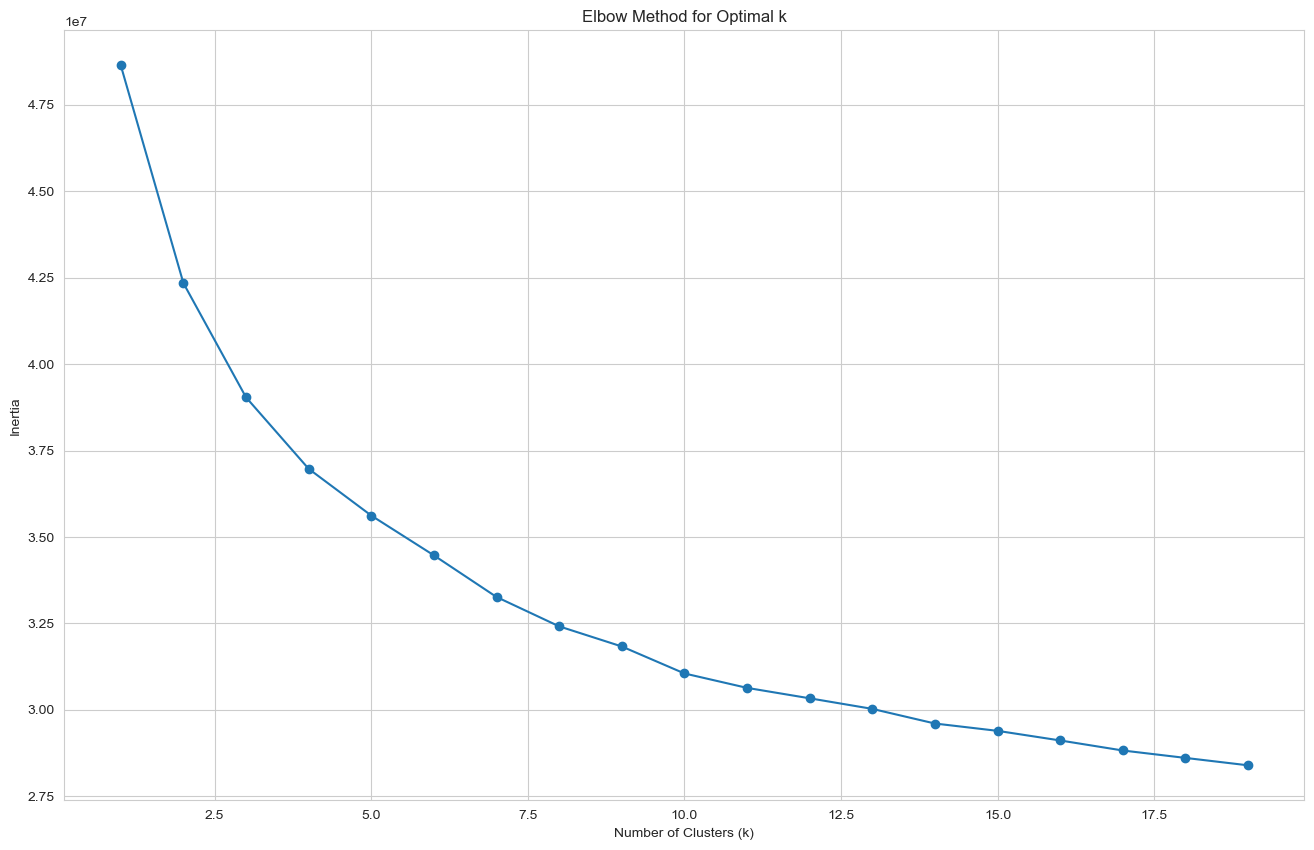

In [32]:
#elbow method to find optimal k
plt.figure(figsize=(16,10))
plt.plot(range(1, 20), [KMeans(n_clusters=i,
               random_state=42).fit(azdias_pca_array).inertia_ for i in range(1, 20)], marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [33]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(azdias_pca_array)
k = kmeans.inertia_
print(f"K-Means Inertia: {k}")

K-Means Inertia: 31053655.68024705


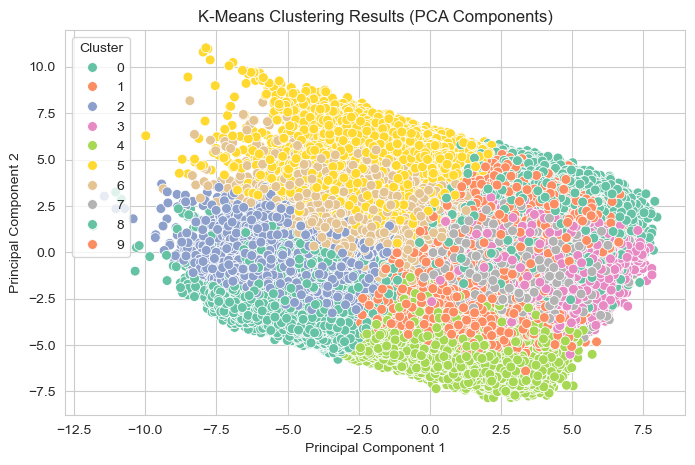

In [34]:
#draw the clustering results using PCA components
plt.figure(figsize=(8,5))
sns.scatterplot(x=azdias_pca_array[:, 0],
                 y=azdias_pca_array[:, 1], hue=kmeans.labels_, palette='Set2', s=50)
plt.title('K-Means Clustering Results (PCA Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

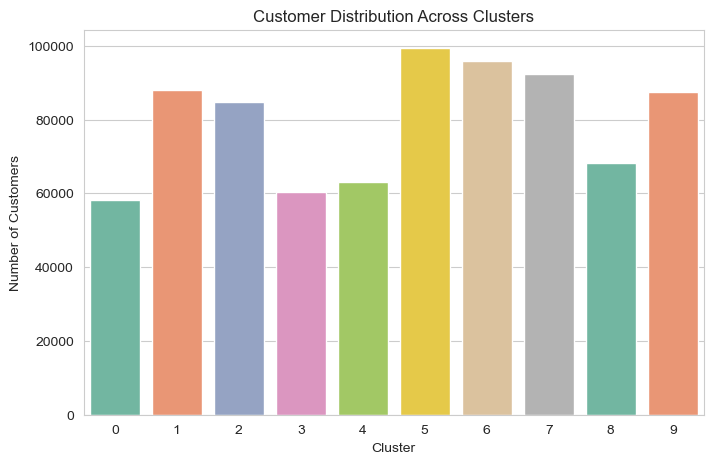

In [35]:
#draw customers distribution across clusters
cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set2')
plt.title('Customer Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()


In [36]:
#calculate the percentage of customers and population in each cluster
cluster_labels = kmeans.labels_
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
cluster_percentages = (cluster_counts / len(cluster_labels)) * 100
for i in range(len(cluster_counts)):
    print(f"Cluster {i}: {cluster_counts[i]} customers ({cluster_percentages[i]:.2f}%)")
    

Cluster 0: 58243 customers (7.30%)
Cluster 1: 87925 customers (11.03%)
Cluster 2: 84692 customers (10.62%)
Cluster 3: 60252 customers (7.56%)
Cluster 4: 63034 customers (7.90%)
Cluster 5: 99397 customers (12.46%)
Cluster 6: 96009 customers (12.04%)
Cluster 7: 92362 customers (11.58%)
Cluster 8: 68104 customers (8.54%)
Cluster 9: 87408 customers (10.96%)


In [37]:
#clean the customers data using the same function to ensure consistency in preprocessing steps
customers_cleaned = clean_data(data2, fsummary)

customers_cleaned = customers_cleaned.reindex(columns = azdias_cleaned.columns, fill_value=0)

customers_imputed = imputer.transform(customers_cleaned)
customers_scaled = scaler.transform(customers_imputed) 
customers_pca_array = pca.transform(customers_scaled)  


In [38]:
#predict the cluster labels for the customers data
customer_cluster_labels = kmeans.predict(customers_pca_array)



In [39]:
#calculate presentage of customers in each cluster
customer_cluster_counts = pd.Series(customer_cluster_labels).value_counts().sort_index()
customer_cluster_percentages = (customer_cluster_counts / len(customer_cluster_labels)) * 100
for i in range(len(customer_cluster_counts)):
    print(f"Cluster {i}: {customer_cluster_counts[i]} customers ({customer_cluster_percentages[i]:.2f}%)")
    

Cluster 0: 17130 customers (12.09%)
Cluster 1: 12271 customers (8.66%)
Cluster 2: 1529 customers (1.08%)
Cluster 3: 47463 customers (33.51%)
Cluster 4: 2720 customers (1.92%)
Cluster 5: 13670 customers (9.65%)
Cluster 6: 15479 customers (10.93%)
Cluster 7: 27691 customers (19.55%)
Cluster 8: 1426 customers (1.01%)
Cluster 9: 2261 customers (1.60%)


In [40]:
#calculate presentage of population in each cluster
population_cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()   
population_cluster_percentages = (population_cluster_counts / len(kmeans.labels_)) * 100
for i in range(len(population_cluster_counts)):
    print(f"Cluster {i}: {population_cluster_counts[i]} population ({population_cluster_percentages[i]:.2f}%)")
    

Cluster 0: 58243 population (7.30%)
Cluster 1: 87925 population (11.03%)
Cluster 2: 84692 population (10.62%)
Cluster 3: 60252 population (7.56%)
Cluster 4: 63034 population (7.90%)
Cluster 5: 99397 population (12.46%)
Cluster 6: 96009 population (12.04%)
Cluster 7: 92362 population (11.58%)
Cluster 8: 68104 population (8.54%)
Cluster 9: 87408 population (10.96%)


In [41]:
#comparing the distribution of customers and population across clusters
customer_cluster_counts = pd.Series(customer_cluster_labels).value_counts().sort_index()
population_cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()
comparison_df = pd.DataFrame({
    'Cluster': customer_cluster_counts.index,
    'Customer Count': customer_cluster_counts.values,
    'Population Count': population_cluster_counts.values
})
print(comparison_df)


   Cluster  Customer Count  Population Count
0        0           17130             58243
1        1           12271             87925
2        2            1529             84692
3        3           47463             60252
4        4            2720             63034
5        5           13670             99397
6        6           15479             96009
7        7           27691             92362
8        8            1426             68104
9        9            2261             87408


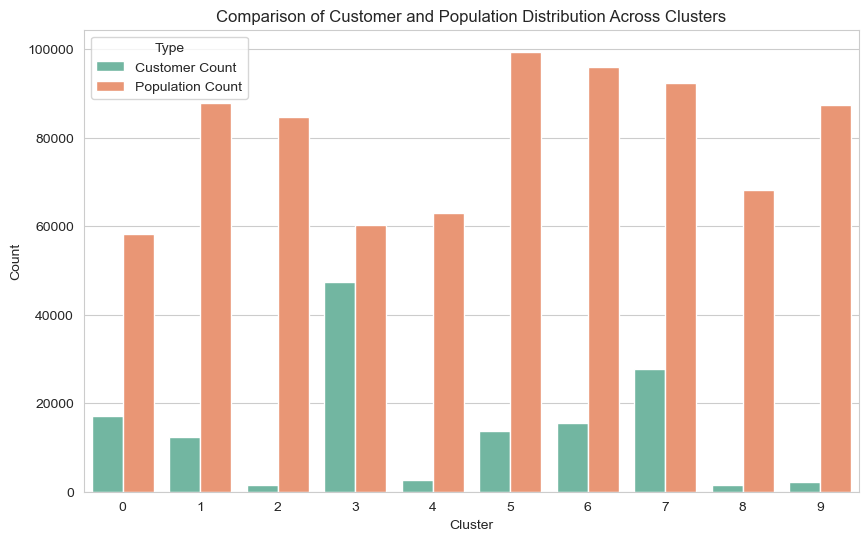

In [42]:
#visualize the comparison of customers and population distribution across clusters
comparison_df_melted = comparison_df.melt(id_vars='Cluster', value_vars=['Customer Count', 'Population Count'], var_name='Type', value_name='Count')
plt.figure(figsize=(10,6))
sns.barplot(x='Cluster', y='Count', hue='Type', data=comparison_df_melted, palette='Set2')
plt.title('Comparison of Customer and Population Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Type')
plt.show()

In [43]:

target_cluster_data = azdias_cleaned[azdias_clusters == 3]

print(target_cluster_data[['ALTERSKATEGORIE_GROB', 'HH_EINKOMMEN_SCORE', 'FINANZ_SPARER']].mean())

NameError: name 'azdias_clusters' is not defined


### **Customer Segmentation Report**

#### **1. Comparison of Customer and General Population Distribution**
In this section, we compare the distribution of the general population and the company's customers across the 10 clusters identified by the K-Means model. The goal is to determine which segments of the population are more likely to be part of the customer base.

* **Over-represented Clusters:** These are segments where the percentage of customers is significantly higher than the percentage of the general population. These represent the company's "Core Target Audience."
* **Under-represented Clusters:** These are segments where the percentage of customers is much lower than their representation in the general population, indicating groups that do not typically engage with the brand.

---

#### **2. Target Cluster Profile (The Ideal Customer)**
Based on the visualization, **Cluster 3** is clearly over-represented among customers. This suggests that the characteristics of individuals in this cluster align closely with the company’s services.

**Key Characteristics of Cluster 3:**
* **Age Structure:** Likely **Elderly or Senior citizens** (as indicated by higher values in `ALTERSKATEGORIE_GROB`).
* **Financial Standing:** Typically **High-income or Wealthy households** (indicated by lower values in `HH_EINKOMMEN_SCORE`).
* **Financial Personality:** They tend to be **Money-savers and Traditionalists** (indicated by lower values in `FINANZ_SPARER`).
* **Social Status:** Often residents in areas with higher purchasing power.

---

#### **3. Under-represented Cluster Profile (The Non-Target Group)**
Conversely, **Cluster 0** (and/or Cluster 5) shows a significant under-representation. While these individuals represent a large portion of the German population, they are not the typical customers for Arvato.

**Key Characteristics of the Under-represented Segment:**
* **Demographics:** This group often consists of **Younger individuals** who may be more socially or digitally oriented but less financially established.
* **Economic Status:** Generally lower income or different spending priorities compared to the target segment.
* **Marketing Insight:** Attempting to reach this group with current marketing materials may result in a lower Return on Investment (ROI).

---

#### **4. Conclusion**
The segmentation analysis reveals that Arvato’s mail-order business is most successful with older, affluent, and financially conservative individuals. Moving forward, the supervised learning model should prioritize these demographics to optimize conversion rates.

